# TU simulation safety parameter plots

In [60]:
import utils
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)

In [31]:
planning_simulations = True

# Determine simulation location
if planning_simulations:
    simulations_location = 'planning'
else:
    simulations_location = 'post-hoc'

# Make output folder
plot_dir = f'/Volumes/kenvdzee/Documents/phd_1_analysis/plots/TUS/acoustic_simulations/{simulations_location}'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

### Find all csv's from the stimulation output folder

In [32]:
simulation_directory = f'/Volumes/project/3025011.02/TUS_simulations/{simulations_location}/'

stimulation_output_full_filenames_1 = os.path.join(simulation_directory, '**', '*layered_output_table_target_1*.csv')
stimulation_output_full_filenames_2 = os.path.join(simulation_directory, '**', '*layered_output_table_target_2*.csv')
stimulation_output_full_filenames_3 = os.path.join(simulation_directory, '**', '*layered_output_table_target_3*.csv')

stimulation_output_full_filenames = glob.glob(stimulation_output_full_filenames_1, recursive=True) + glob.glob(stimulation_output_full_filenames_2, recursive=True) + glob.glob(stimulation_output_full_filenames_3, recursive=True)
print(stimulation_output_full_filenames)

['/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-052/sub-052_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-053/sub-053_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-054/sub-054_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-055/sub-055_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-057/sub-057_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-206/sub-206_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-061/sub-061_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/

### Save them in one dataframe
And add columns with the individual subject_id's, targets etc

In [33]:
# List to hold individual dataframes
list_of_dataframes = []

# Process each CSV file
for stimulation_output_full_filename in stimulation_output_full_filenames:
    # Extract the filename (without the path)
    stimulation_output_filename = os.path.basename(stimulation_output_full_filename)
    # Remove the '.csv' extension
    stimulation_output_filename_without_extension = os.path.splitext(stimulation_output_filename)[0]
    
    # Split the filename by underscores
    stimulation_output_filename_parts = stimulation_output_filename_without_extension.split('_')
    
    # Extract the desired parts from the filename:
    subject_id = stimulation_output_filename_parts[0]                     # e.g. 'sub-010'
    target = '_'.join(stimulation_output_filename_parts[4:7])               # e.g. 'target_2_2'
    
    # Read the CSV file (assuming it contains one row)
    try:
        df = pd.read_csv(stimulation_output_full_filename)
    except Exception as e:
        print(f"Error reading {stimulation_output_full_filename}: {e}")
        continue  # Skip this file if there's an error

    # Add the extracted metadata as new columns
    df['target'] = target
    
    # Append the dataframe to our list
    list_of_dataframes.append(df)

# Combine all dataframes into one
if list_of_dataframes:
    stimulation_output = pd.concat(list_of_dataframes, ignore_index=True)
    print(stimulation_output)
else:
    raise Exception("No CSV files were found or processed.")

     subject_id  max_Isppa  max_Isppa_after_exit_plane  real_focal_distance  \
0            52   30.24333                    20.65911             0.000000   
1            53   34.03748                    14.18608             1.500000   
2            54   34.50002                    13.69930             3.500000   
3            55   28.57950                    15.28616             1.000000   
4            57   37.13649                    14.22660             3.000000   
..          ...        ...                         ...                  ...   
181          61   13.97250                    13.97250            12.509996   
182          58   14.26690                    14.26690            14.000000   
183          64   19.00941                    19.00941            12.000000   
184          60   10.08785                    10.08785            12.500000   
185          67   19.77414                    19.77414            13.000000   

     max_Isppa_skin  max_Isppa_skull  max_Isppa_bra

### Reorder the dataframe and replace strings

In [34]:
# Reorder columns
column_indices = list(range(stimulation_output.shape[1]))
reordered_column_indices = [column_indices[0]] + column_indices[-3:] + column_indices[1:-3]
stimulation_output = stimulation_output.iloc[:, reordered_column_indices]
stimulation_output.sort_values(by=['subject_id', 'target'], inplace=True)
stimulation_output.reset_index(drop=True, inplace=True)

# Now drop some columns
stimulation_output.drop(
    ['real_focal_distance','Ix_brain', 'Iy_brain','Iz_brain',
     'focus_pos_final_1', 'focus_pos_final_2', 'focus_pos_final_3',
     'trans_pos_final_1', 'trans_pos_final_2', 'trans_pos_final_3'],
    axis=1,
    inplace=True
)

# Split target up into two
stimulation_output[['main_target', 'sub_target']] = stimulation_output['target'].str.extract(r'(target_\d+)_(\d+)')

print(stimulation_output)

     subject_id  CEM43_end_skull  CEM43_end_skin      target  max_Isppa  \
0            52         0.000986        0.000603  target_1_1   30.24333   
1            52         0.001515        0.001061  target_1_2   29.18617   
2            52         0.002753        0.001812  target_1_3   30.24333   
3            52         0.003712        0.002655  target_1_4   29.18617   
4            52         0.004877        0.003286  target_1_5   30.24333   
..          ...              ...             ...         ...        ...   
181         206         0.002452        0.001030  target_1_2   38.68074   
182         206         0.004392        0.002053  target_1_3   45.58873   
183         206         0.004898        0.002369  target_1_4   37.35425   
184         206         0.007942        0.003804  target_1_5   45.58873   
185         206         0.008870        0.004195  target_1_6   37.35425   

     max_Isppa_after_exit_plane  max_Isppa_skin  max_Isppa_skull  \
0                      20.65911

# Mechanical index
1.9 is the safety limit
Group by target and intensity

In [35]:
safety_limit = 1.9

## Skin

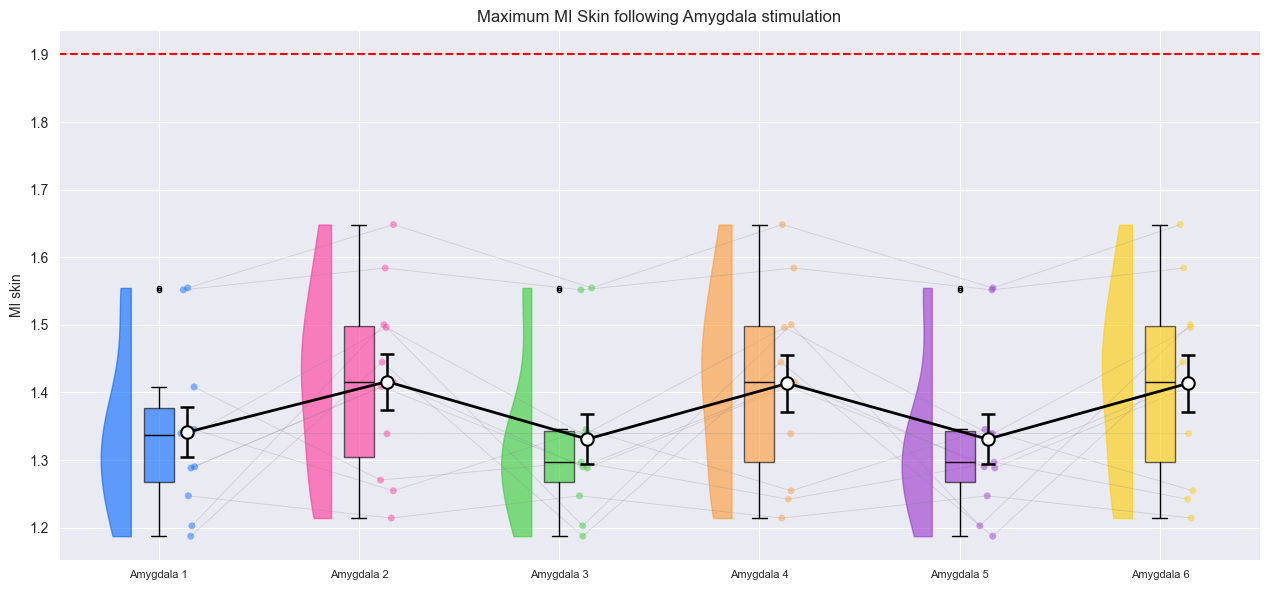

In [36]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='MI skin',
    hline=safety_limit,
    plot_name='Maximum MI Skin following Amygdala stimulation'
);

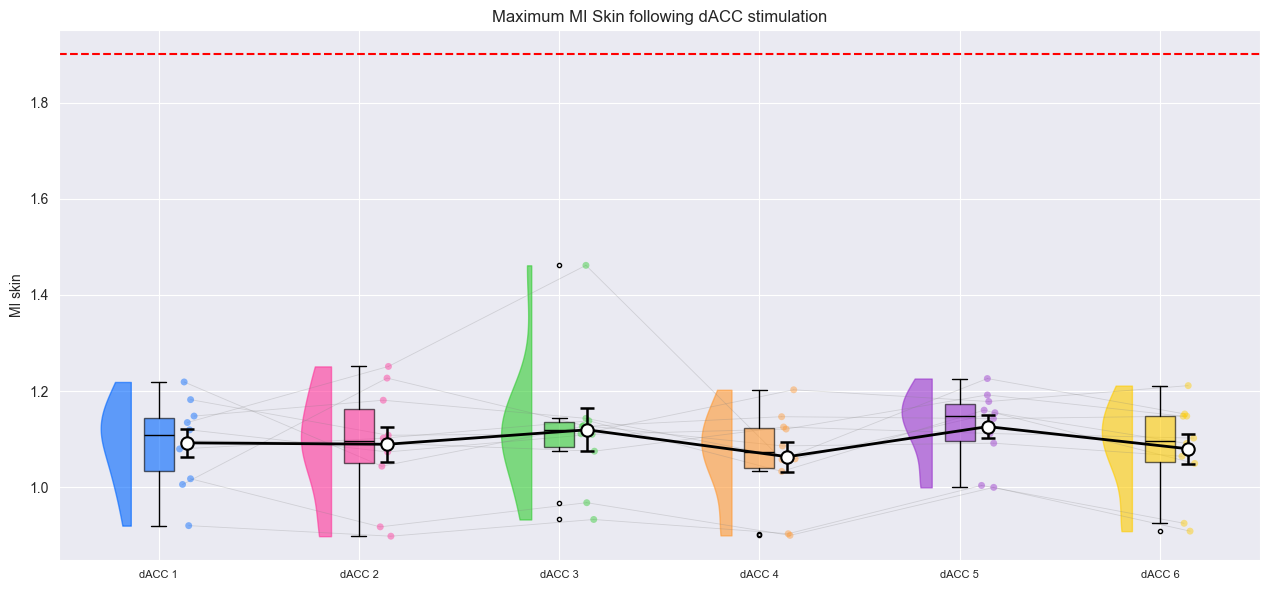

In [37]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='MI skin',
    hline=safety_limit,
    plot_name='Maximum MI Skin following dACC stimulation'
);

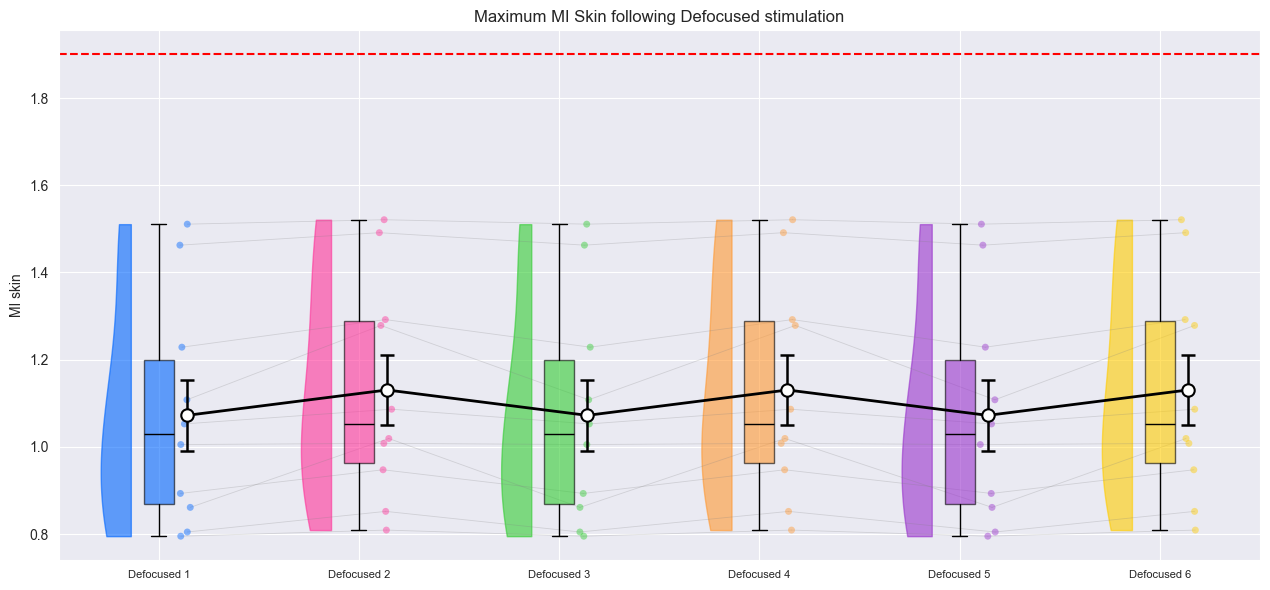

In [38]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='MI skin',
    hline=safety_limit,
    plot_name='Maximum MI Skin following Defocused stimulation'
);

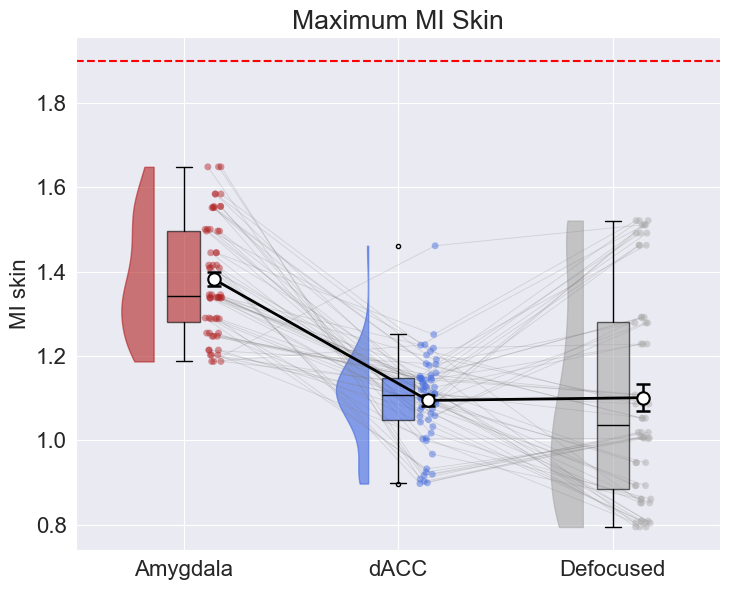

In [39]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='MI skin',
    hline=safety_limit,
    plot_name='Maximum MI Skin',
    font_scale=1.6
);

## Brain

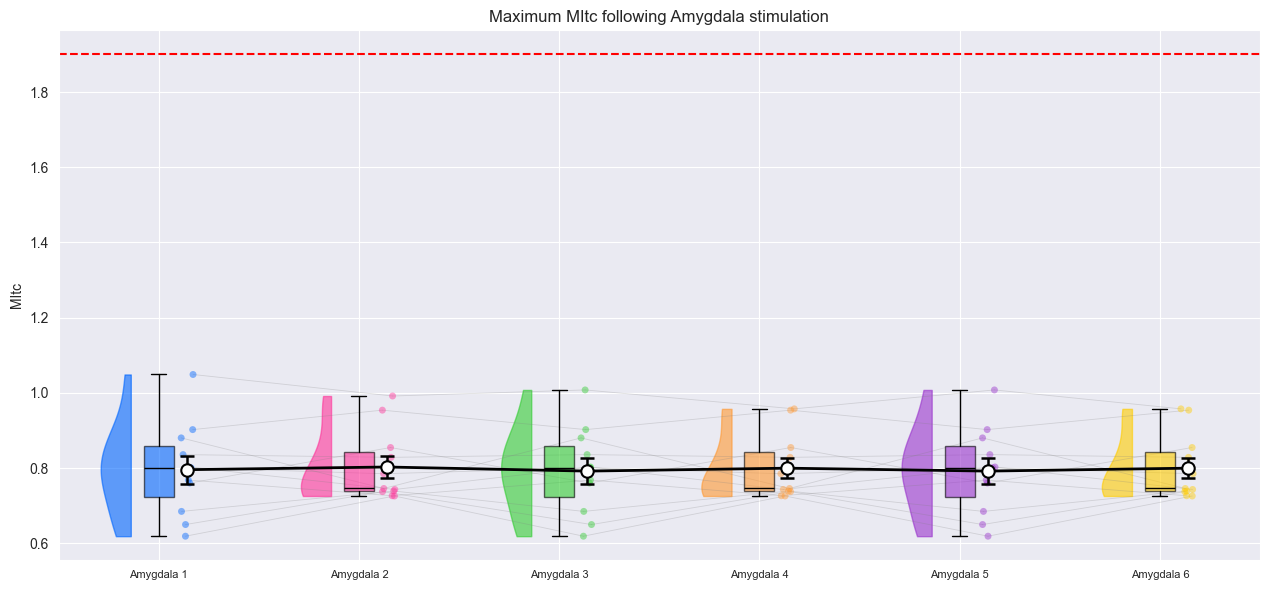

In [40]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='MItc',
    hline=safety_limit,
    plot_name='Maximum MItc following Amygdala stimulation'
);

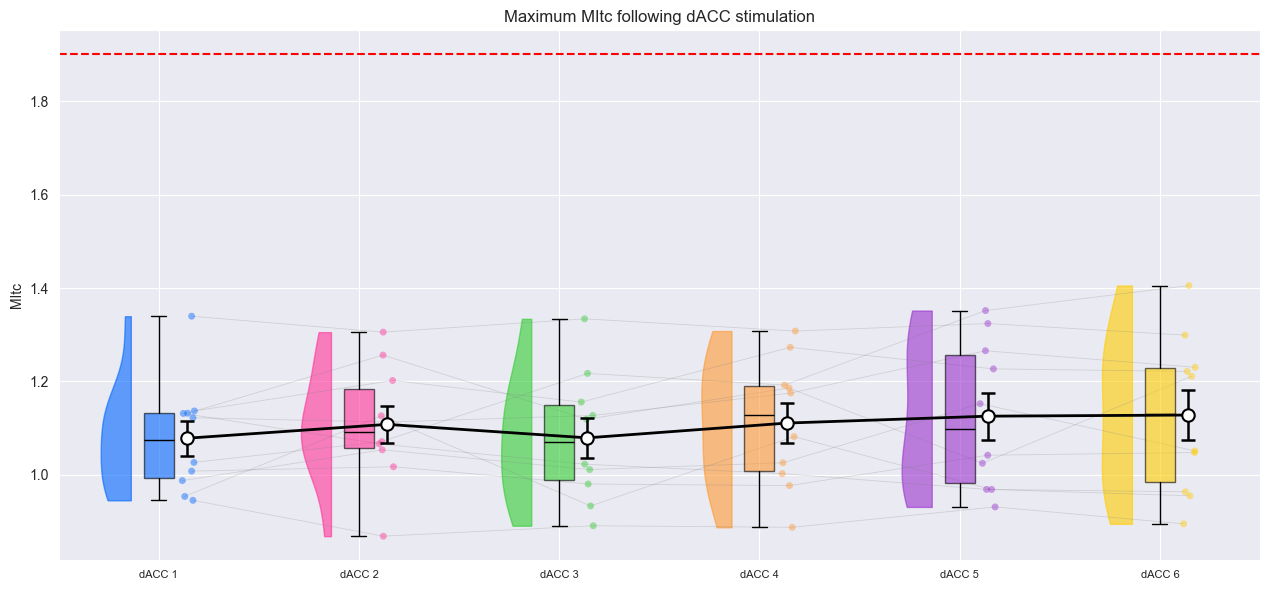

In [41]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='MItc',
    hline=safety_limit,
    plot_name='Maximum MItc following dACC stimulation'
);

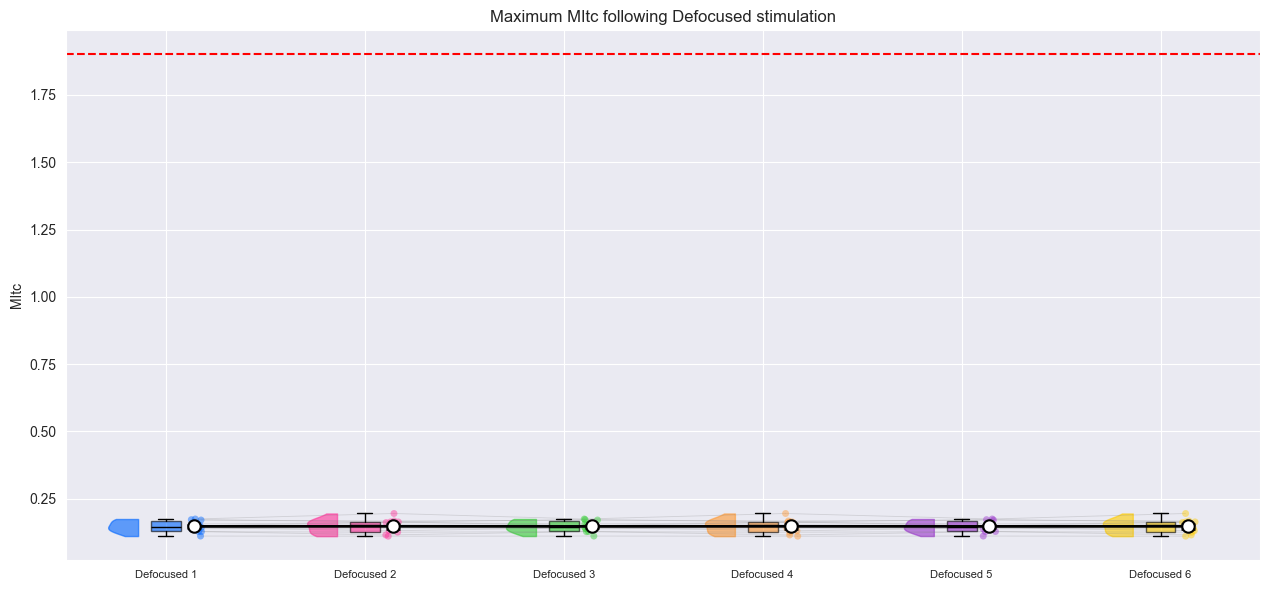

In [42]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='MItc',
    hline=safety_limit,
    plot_name='Maximum MItc following Defocused stimulation'
);

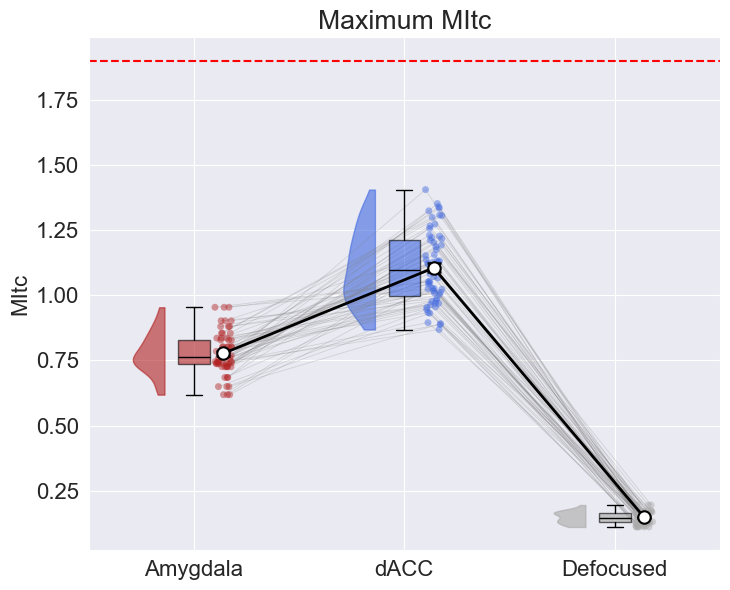

In [43]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='MItc',
    hline=safety_limit,
    plot_name='Maximum MItc',
    font_scale=1.6
);

# CEM43
0.25 is the safety limit
Group by target and intensity

## Skin

In [44]:
safety_limit = 21

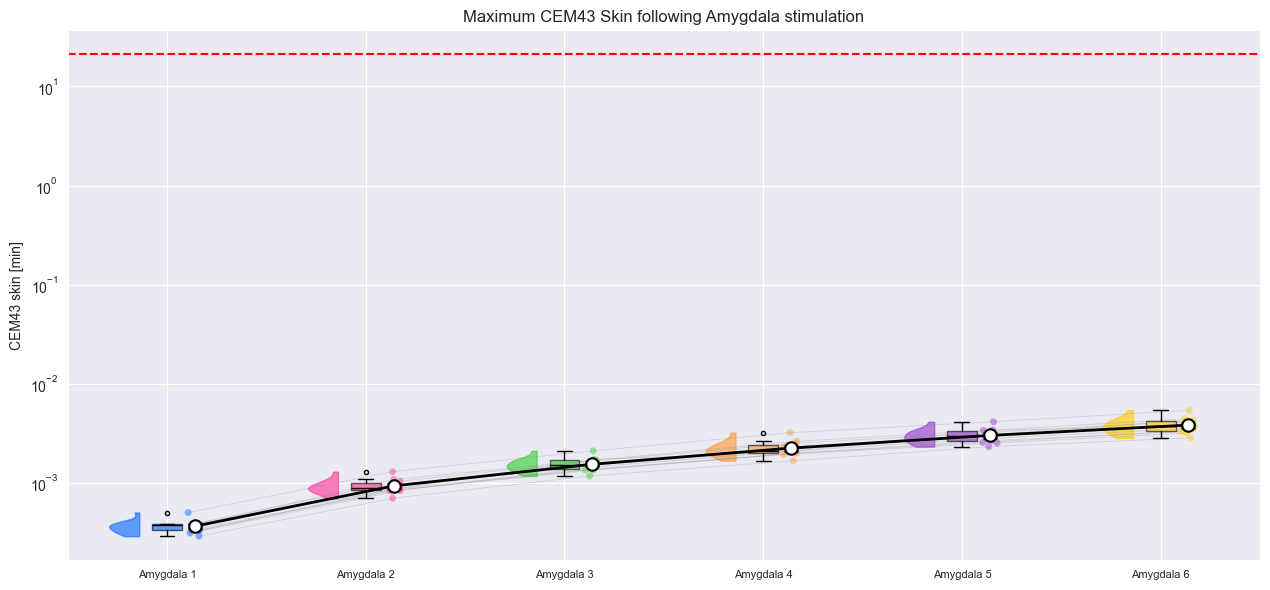

In [45]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skin [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 Skin following Amygdala stimulation',
    logarithmic_scale=True
);

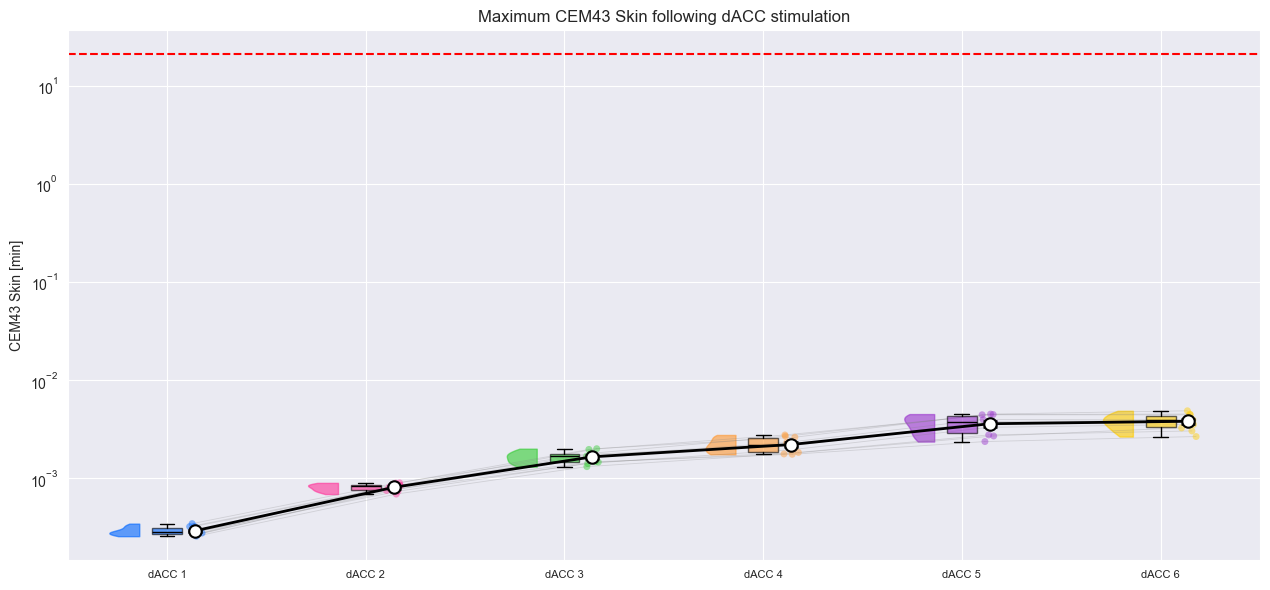

In [46]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 Skin [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 Skin following dACC stimulation',
    logarithmic_scale=True
);

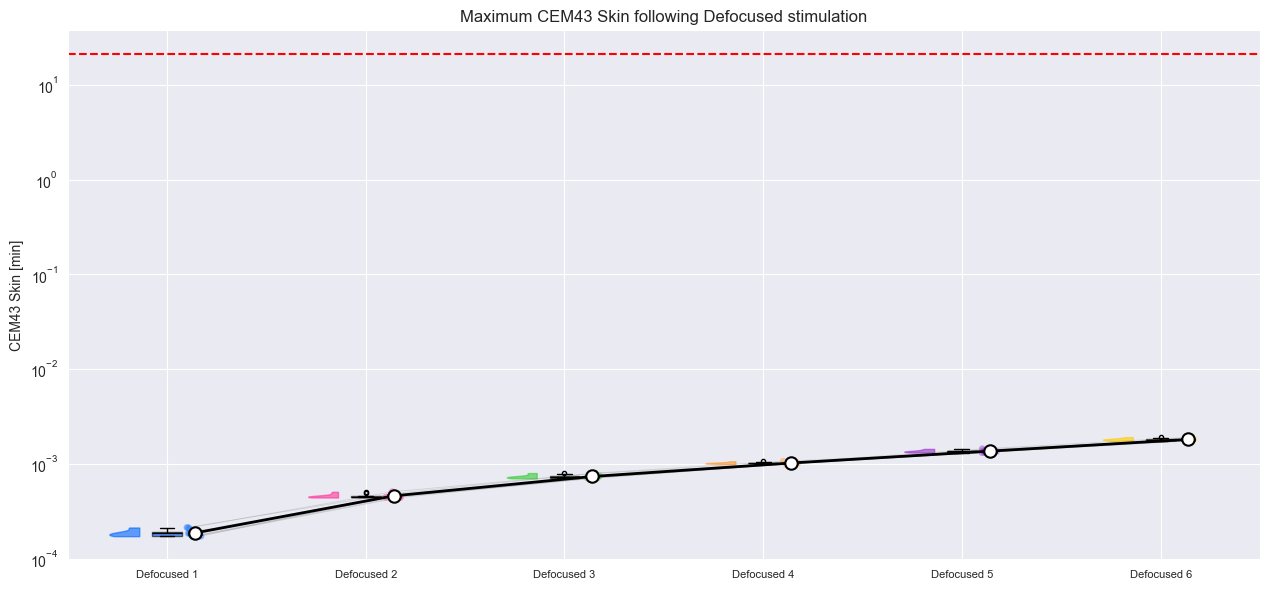

In [47]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 Skin [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 Skin following Defocused stimulation',
    logarithmic_scale=True
);

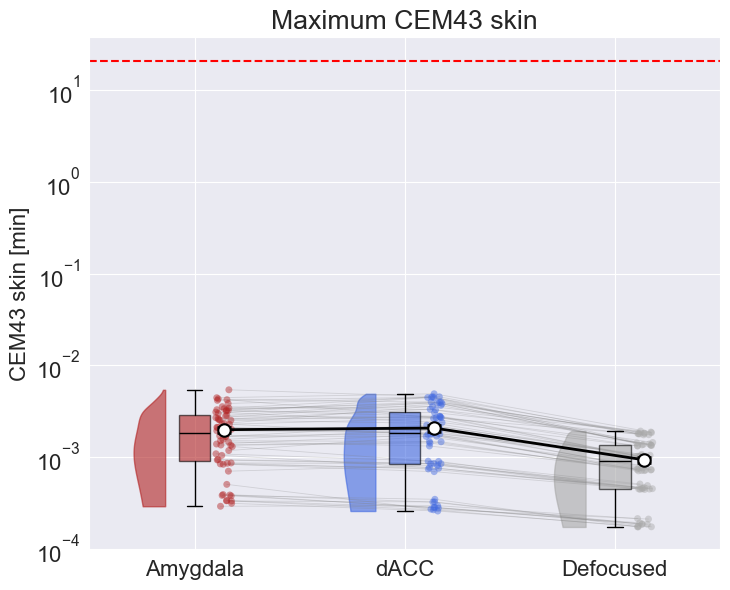

In [48]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skin [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skin',
    logarithmic_scale=True,
    font_scale=1.6
);

## Brain

In [49]:
safety_limit = 2

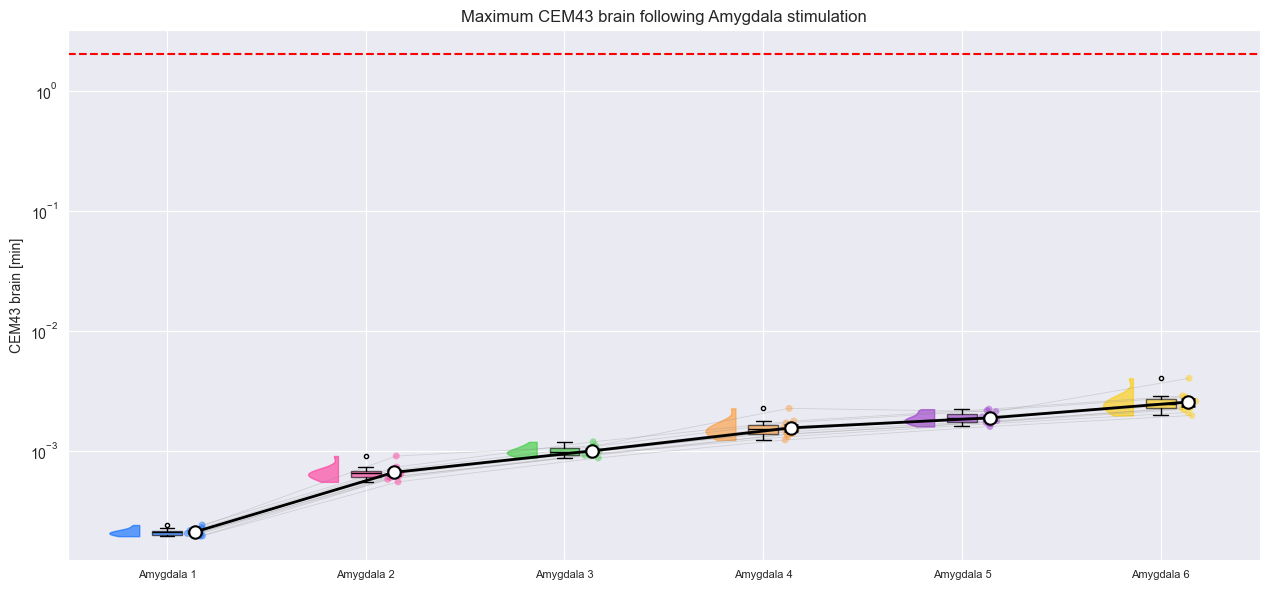

In [50]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 brain [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain following Amygdala stimulation',
    logarithmic_scale=True
);

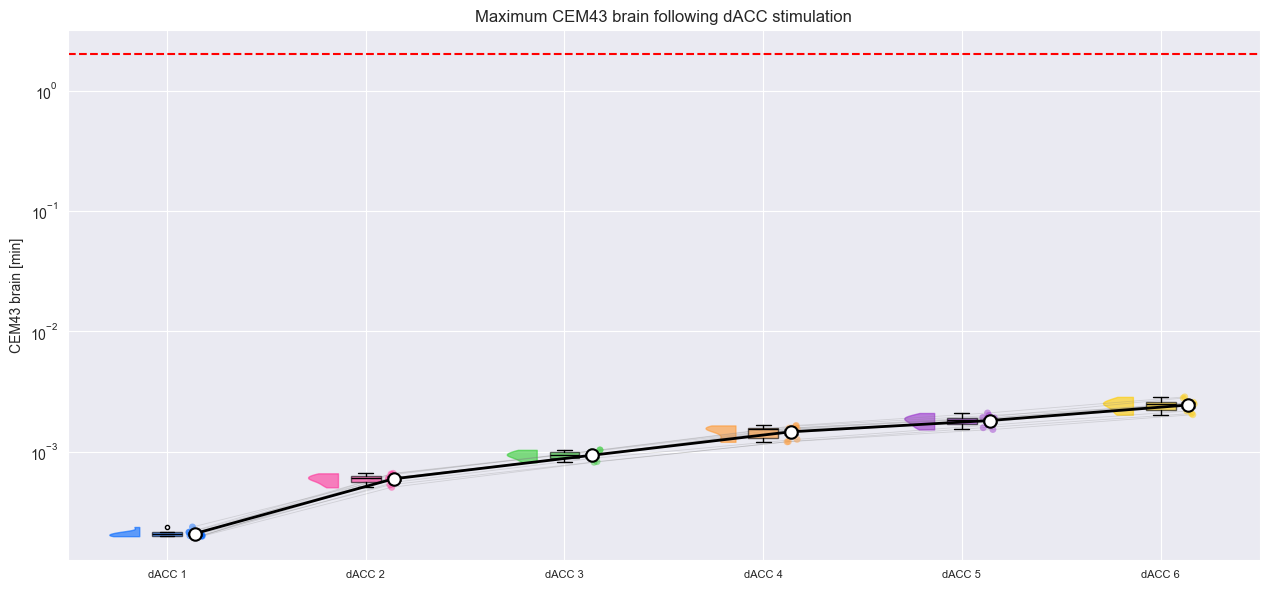

In [51]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 brain [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain following dACC stimulation',
    logarithmic_scale=True
);

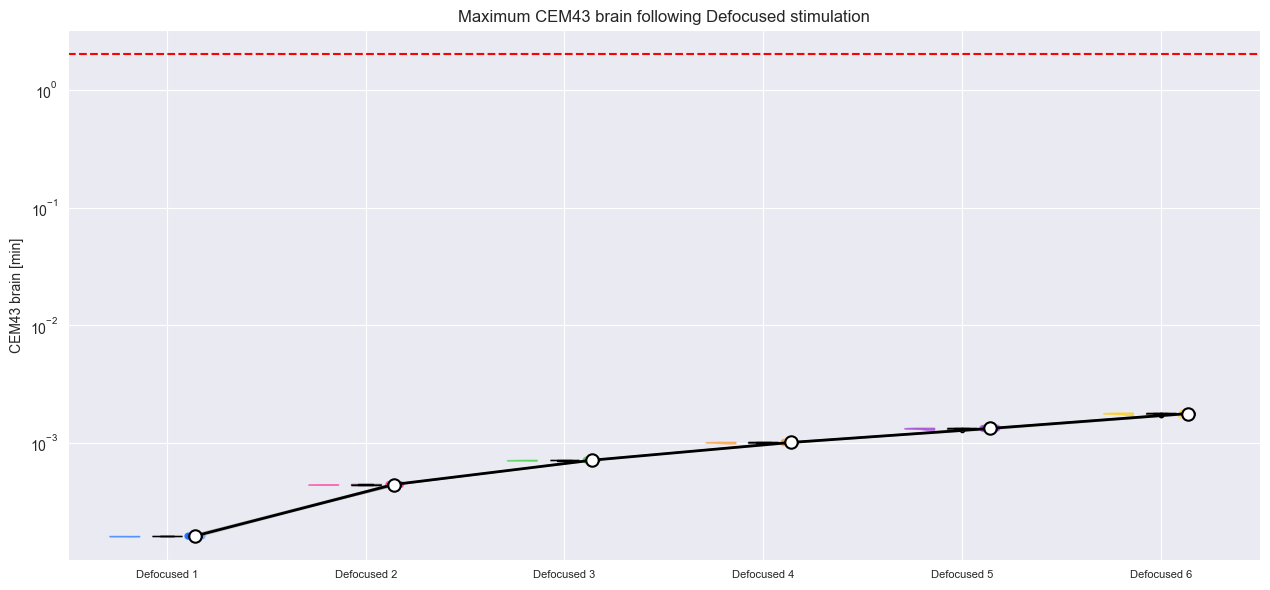

In [52]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 brain [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain following Defocused stimulation',
    logarithmic_scale=True
);

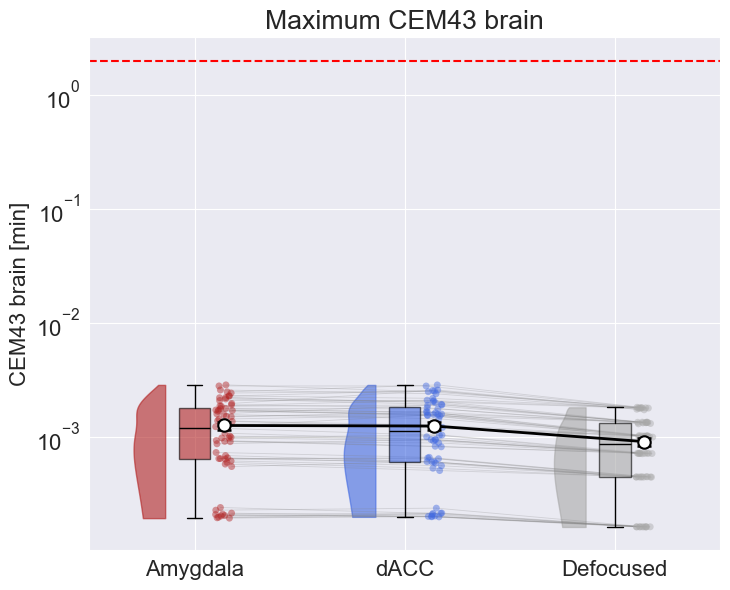

In [53]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='CEM43 brain [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain',
    logarithmic_scale=True,
    font_scale=1.6
);

## Skull

In [54]:
safety_limit = 16

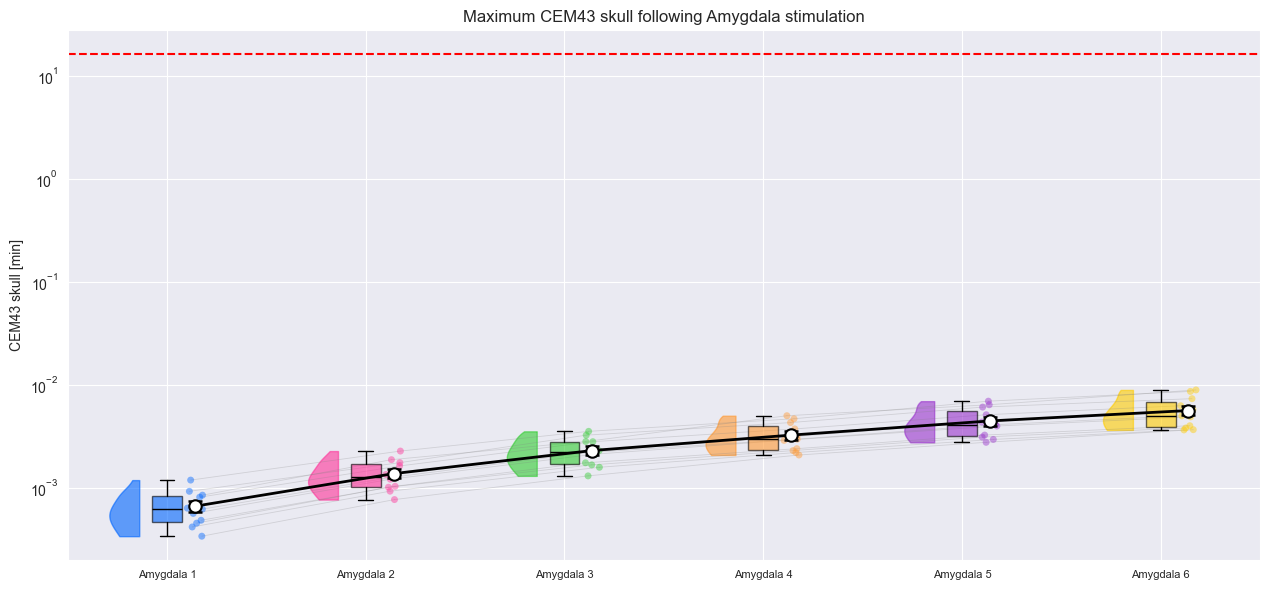

In [55]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skull [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull following Amygdala stimulation',
    logarithmic_scale=True
);

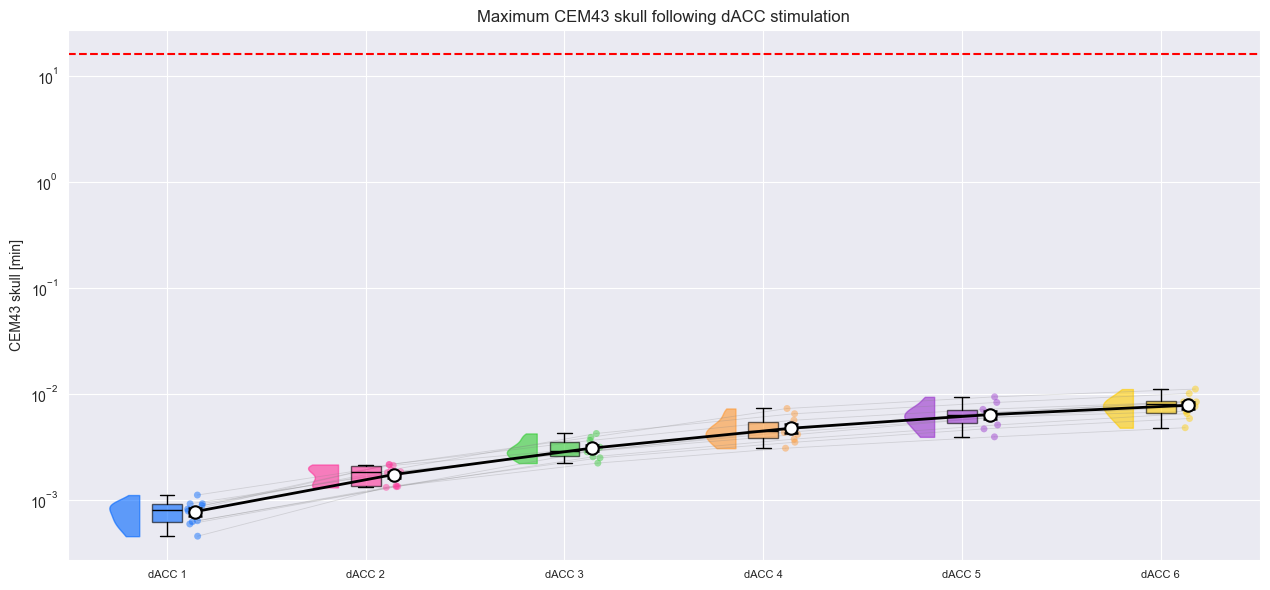

In [56]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skull [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull following dACC stimulation',
    logarithmic_scale=True
);

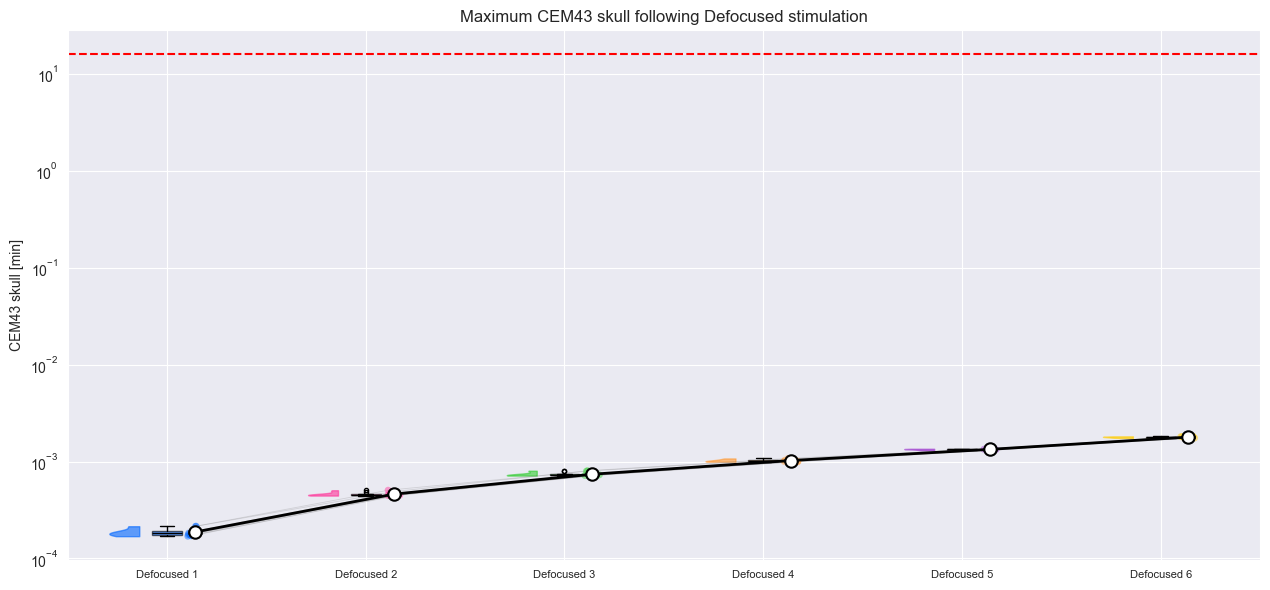

In [57]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skull [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull following Defocused stimulation',
    logarithmic_scale=True
);


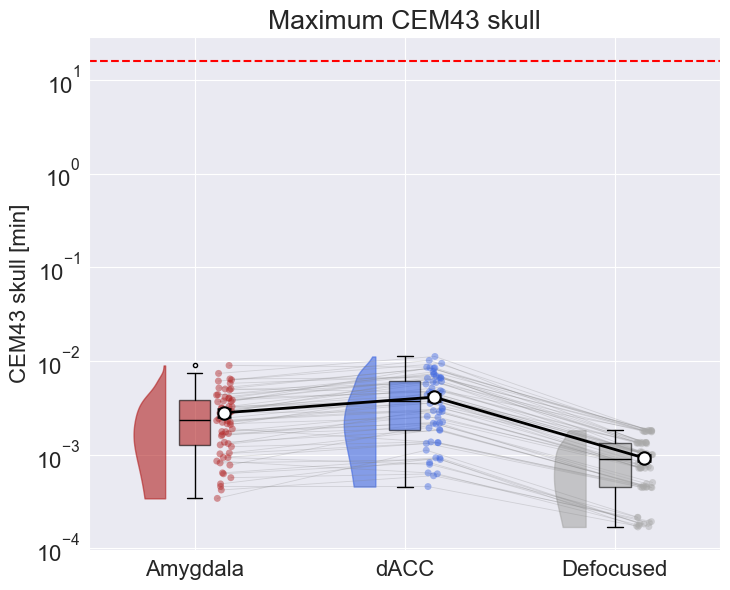

In [58]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skull [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull',
    logarithmic_scale=True,
    font_scale=1.6
);